<a href="https://colab.research.google.com/github/Eikthyrnir/uam-cv-sim-to-real-interpretability/blob/main/DIMO_detection_sandbox.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Wizja komputerowa, dane syntetyczne i testowanie architektur

**Projekty dla studentów V roku / ostatniego semestru. Realizacja w parach dwuosobowych.**

# **Zasady ogólne**

**Każdy projekt jest realizowany przez dokładnie dwie osoby.** Temat ma prowadzić do kompletnego, mierzalnego eksperymentu z użyciem modeli wizyjnych: klasyfikacji, detekcji, segmentacji, pseudoetykietowania, samonadzorowanego uczenia reprezentacji albo analizy luki domenowej. Projekty mogą mocniej akcentować generowanie danych syntetycznych albo testowanie architektur, ale każdy projekt musi kończyć się wynikami ilościowymi i jakościowymi.

· Każda para musi udostępnić publiczne lub dostępne dla prowadzącego repozytorium GitHub z kodem, konfiguracjami, instrukcją uruchomienia, skryptami przygotowania danych i wynikami eksperymentów.

· Każda para musi przygotować dokument wynikowy, najlepiej w formacie PDF lub Google Docs, opisujący cel, dane, metody, architektury, eksperymenty, wyniki, wizualizacje, błędy i ograniczenia.

· Link do repozytorium oraz link do dokumentu wynikowego muszą zostać wpisane do arkusza Google Sheets: [arkusz projektów](https://docs.google.com/spreadsheets/d/1HeEo42lNxoAGrou7ehcJk4KBIXR4Gv7RgMd3FmzLE0I/edit?usp=sharing).

· W arkuszu powinny znaleźć się co najmniej: numer projektu, imiona i nazwiska studentów, link do repozytorium, link do raportu, link do danych/artefaktów/modeli, krótki opis finalnego wariantu eksperymentu oraz status projektu.

· Zbiory danych wskazane poniżej są publicznie dostępne lub powszechnie używane w badaniach. Przed użyciem należy sprawdzić i respektować licencję konkretnego zbioru, obrazu i adnotacji; nie wszystkie zbiory są stricte CC0/public domain.

# **Minimalny zakres wyników**

· Dla lżejszych projektów klasyfikacyjnych lub segmentacyjnych oczekiwane jest około 15-30 sensownych konfiguracji lub wariantów eksperymentalnych.

· Dla cięższych projektów detekcyjnych oczekiwane jest około 8-15 konfiguracji, ale z pełniejszą analizą kosztu obliczeniowego, błędów i transferu domenowego.

· Każdy projekt musi zawierać punkt odniesienia, warianty porównawcze, tabele metryk, wykresy, wizualizacje wyników, przykłady błędów oraz interpretowalność: Grad-CAM, mapy uwagi, aktywacje, filtry lub osadzenia.

· Raport powinien mieć strukturę krótkiego artykułu: wstęp i pytanie badawcze, przegląd literatury, opis danych, metoda, protokół eksperymentów, wyniki, analiza jakościowa, ograniczenia, wnioski i instrukcja reprodukcji.


## **7\. Co sieci naprawdę uczą się z danych syntetycznych? Aktywacje, filtry i skróty decyzyjne**

**Kierunek:** interpretowalność / testowanie architektur

**Zadanie wizyjne:** klasyfikacja lub detekcja

**Publicznie dostępne zbiory danych:** COCO, Open Images, własny zbiór Blender, RarePlanes

**Pytanie badawcze:** Czy model trenowany na syntetykach uczy się obiektu, czy raczej artefaktów renderingu, tła, tekstur i innych skrótów decyzyjnych?

**Opis projektu:** To projekt diagnostyczny. Para trenuje ten sam model na różnych reżimach danych: tylko dane rzeczywiste, tylko dane syntetyczne, słaba randomizacja syntetyczna, silna randomizacja syntetyczna i mieszanka danych. Następnie analizuje aktywacje warstw, mapy uwagi, Grad-CAM oraz przypadki błędów. Celem jest wykrycie, kiedy syntetyki tworzą bias tła, bias tekstury lub bias kształtu.

**Modele i metody do przetestowania:**

· ResNet/ConvNeXt dla klasyfikacji

· YOLOv10 lub Faster R-CNN dla detekcji

· ViT/DINOv2 dla analizy uwagi

**Wymagane eksperymenty:**

· porównanie 4-5 reżimów danych

· analiza wrażliwości na zasłanianie fragmentów obrazu: usuwanie tła, tekstury, części obiektu

· UMAP/t-SNE osadzeń cech dla danych rzeczywistych i syntetycznych

· analiza 50 poprawnych i 50 błędnych predykcji

**Wymagane wyniki i analiza:**

· dokładność lub mAP

· co najmniej 50 wizualizacji Grad-CAM / mapy uwagi

· mapy filtrów lub aktywacji wybranych warstw

· ranking najczęstszych skrótów decyzyjnych

· sekcja w raporcie: kiedy syntetyki pomagają, a kiedy szkodzą

**Linki:** [pytorch-grad-cam](https://github.com/jacobgil/pytorch-grad-cam); [DINOv2](https://github.com/facebookresearch/dinov2); [COCO](https://cocodataset.org/); [Open Images](https://storage.googleapis.com/openimages/web/index.html); [RarePlanes](https://www.iqt.org/library/the-rareplanes-dataset); [ConvNeXt V2](https://github.com/facebookresearch/ConvNeXt-V2)


## Step 1: Mount Google Drive
To avoid downloading massive files every time your session disconnects, we can save the dataset to Google Drive (if you have enough space). Otherwise, you can use the local `/content/` storage, but remember it will be cleared after the session ends.

In [3]:
from google.colab import drive
import os

# Mount Google Drive (Optional but recommended if you have space)
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2: Download the Dataset

### Download from official DIMO links to Google Drive (Slow)

In [ ]:
PROJECT_DIR = '/content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO'

os.makedirs(PROJECT_DIR, exist_ok=True)

In [ ]:
TAR_PATH = os.path.join(PROJECT_DIR, "dimo.tar")

In [ ]:
DATASET_URL = "https://datasets.ilabt.imec.be/dimo/tar/dimo.tar"


# Download only if it doesn't exist yet
if not os.path.exists(TAR_PATH):
    !wget -O "{TAR_PATH}" "{DATASET_URL}"

--2026-05-27 19:20:14--  https://datasets.ilabt.imec.be/dimo/tar/dimo.tar
Resolving datasets.ilabt.imec.be (datasets.ilabt.imec.be)... 193.191.148.201, 2001:6a8:1d80:26::201
Connecting to datasets.ilabt.imec.be (datasets.ilabt.imec.be)|193.191.148.201|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14153728 (13M) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/dimo.tar’

/content/drive/MyDr 100%[===================>]  13.50M  5.44MB/s    in 2.5s    

2026-05-27 19:20:18 (5.44 MB/s) - ‘/content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/dimo.tar’ saved [14153728/14153728]



#### Download Real-World Data (RealSense D415)
Since the project involves comparing real and synthetic data, let's start with the smallest real-world image archive (RealSense D415, 12.7 GB). Replace the URL below with the actual link to this archive.

In [ ]:
REAL_DATA_URL = "https://datasets.ilabt.imec.be/dimo/tar/real_d415.tar"
REAL_TAR_PATH = os.path.join(PROJECT_DIR, "real_d415.tar")

if not os.path.exists(REAL_TAR_PATH):
    !wget -O "{REAL_TAR_PATH}" "{REAL_DATA_URL}"

#### Download dimo small

In [ ]:
REAL_DATA_URL = "https://datasets.ilabt.imec.be/dimo/tar/dimo_small.tar"
REAL_TAR_PATH = os.path.join(PROJECT_DIR, "dimo_small.tar")

if not os.path.exists(REAL_TAR_PATH):
    !wget -O "{REAL_TAR_PATH}" "{REAL_DATA_URL}"

--2026-05-28 13:15:38--  https://datasets.ilabt.imec.be/dimo/tar/dimo_small.tar
Resolving datasets.ilabt.imec.be (datasets.ilabt.imec.be)... 193.191.148.201, 2001:6a8:1d80:26::201
Connecting to datasets.ilabt.imec.be (datasets.ilabt.imec.be)|193.191.148.201|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 65892688896 (61G) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/dimo_small.tar’

/content/drive/MyDr   1%[                    ]   1.01G  9.15MB/s    in 97s     

2026-05-28 13:17:16 (10.6 MB/s) - Connection closed at byte 1080401777. Retrying.

--2026-05-28 13:17:17--  (try: 2)  https://datasets.ilabt.imec.be/dimo/tar/dimo_small.tar
Connecting to datasets.ilabt.imec.be (datasets.ilabt.imec.be)|193.191.148.201|:443... connected.
HTTP request sent, awaiting response... 206 Partial Content
Length: 65892688896 (61G), 64812287119 (60G) remaining [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/UAM/Magister

### Download from Tim's Google Drive (much faster)

In [1]:
!mkdir /content/DIMO_archives

In [ ]:
# !gdown --id 1py7xaJpql7a6SrS9N5JF0xANLpbYZ4yM -O /content/DIMO_archives/dimo.tar

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1py7xaJpql7a6SrS9N5JF0xANLpbYZ4yM
To: /content/DIMO_archives/dimo.tar
100% 14.2M/14.2M [00:00<00:00, 81.7MB/s]


In [ ]:
# !gdown --id 1TyINalV-nfdbbalOzcebp4tH9_K-ibI5 -O /content/DIMO_archives/real_d415.tar

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1TyINalV-nfdbbalOzcebp4tH9_K-ibI5
From (redirected): https://drive.google.com/uc?id=1TyINalV-nfdbbalOzcebp4tH9_K-ibI5&confirm=t&uuid=d9e7b407-441f-4897-8452-d57a85995fc6
To: /content/DIMO_archives/real_d415.tar
100% 12.7G/12.7G [02:55<00:00, 72.6MB/s]


In [2]:
!gdown 1xCHhENLfAZDgOErz4TWL-FhMBnJ8uhVO -O /content/DIMO_archives/dimo_small.tar

Failed to retrieve file url:

	Too many users have viewed or downloaded this file recently. Please
	try accessing the file again later. If the file you are trying to
	access is particularly large or is shared with many people, it may
	take up to 24 hours to be able to view or download the file. If you
	still can't access a file after 24 hours, contact your domain
	administrator.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1xCHhENLfAZDgOErz4TWL-FhMBnJ8uhVO

but Gdown can't. Please check connections and permissions.


In [ ]:
# alternative
!cp /content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/dimo_small.tar /content/DIMO_archives/dimo_small.tar

In [ ]:
!cd /content/DIMO_archives && ls -la

total 64348384
drwxr-xr-x 2 root root        4096 May 29 07:41 .
drwxr-xr-x 1 root root        4096 May 29 07:41 ..
-rw------- 1 root root 65892688896 May 29 08:10 dimo_small.tar


## Upzip

### dimo-small

In [4]:
!tar -xf /content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/dimo_small.tar -C /content

Streaming output truncated to the last 5000 lines.
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar

In [ ]:
!tar -xf /content/DIMO_archives/dimo_small.tar -C /content

Streaming output truncated to the last 5000 lines.
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar

### Full-size (HD) real data

In [ ]:
!tar -xf /content/DIMO_archives/dimo.tar -C /content

tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'SCHILY.fflags'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.FinderInfo'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.lastuseddate#PS'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.metadata:_kMDItemUserTags'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.macl'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.macl'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.lastuseddate#PS'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.macl'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.macl'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.mac

In [ ]:
!tar -xf /content/DIMO_archives/real_d415.tar -C /content/dimo

## Step 6: Parse Annotations and Visualize Ground Truth


In [6]:
# We will use trimesh to easily load the 3D .ply models
!pip install trimesh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 20.5 MB/s eta 0:00:00


### Load Dataset using Official DIMO Loader
Instead of parsing JSONs manually, let's use the provided `dimo_loader.py` to structure the dataset.

In [7]:
!git clone https://github.com/pderoovere/dimo.git /content/dimo_repo

Cloning into '/content/dimo_repo'...
remote: Enumerating objects: 221, done.
remote: Counting objects: 100% (221/221), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 221 (delta 88), reused 185 (delta 61), pack-reused 0 (from 0)
Receiving objects: 100% (221/221), 6.44 MiB | 14.19 MiB/s, done.
Resolving deltas: 100% (88/88), done.


In [8]:
import sys
import os
# Ensure the current directory is in the path to import dimo_loader
if '/content' not in sys.path:
    sys.path.append('/content')

from dimo_repo.scripts.dimo_loader import DimoLoader
from pathlib import Path

In [9]:
# Set path to the extracted dimo dataset folder
dimo_ds_path = Path('/content/dimo_small')

In [10]:
dimo_loader = DimoLoader()

# Pass cameras=["real_d415"] to specify the folder to load instead of defaulting to real_jaigo
dimo_ds = dimo_loader.load(dimo_ds_path,
                           cameras=[
                               "real_d415",
                               "real_jaigo",
                               "real_l515",
                               "real_mvbluefox",
                               "sim_jaigo"
                            ]
                           )

Loading real_d415
Loading real_jaigo
Loading real_l515
Loading real_mvbluefox
Loading sim_jaigo


In [11]:
# Let's inspect what was loaded
print("\n--- Dataset Summary ---")
print("Top-level keys:", list(dimo_ds.keys()))
print(f"Number of 3D models loaded: {len(dimo_ds['models'])}")

# Now the data will be keyed as 'real_d415' and we know it's a list of scenes
real_scenes = dimo_ds['real_jaigo']

print(f"Number of scenes: {len(real_scenes)}")

first_scene = real_scenes[0]
print(f"Scene ID {first_scene['id']} contains {len(first_scene['images'])} images.")

# Let's look at the first image's keys
first_img = first_scene['images'][0]
print(f"First image keys: {list(first_img.keys())}")
print(f"Number of objects in first image: {len(first_img['objects'])}")


--- Dataset Summary ---
Top-level keys: ['models', 'real_d415', 'real_jaigo', 'real_l515', 'real_mvbluefox', 'sim_jaigo']
Number of 3D models loaded: 6
Number of scenes in 'real_d415': 600
Scene ID 000000 contains 13 images.
First image keys: ['id', 'path', 'camera', 'scene_info', 'objects']
Number of objects in first image: 1


In [12]:
dimo_ds['sim_jaigo'][0]['images'][1]

{'id': 1,
 'path': PosixPath('/content/dimo_small/sim_jaigo/000000_00/rgb/000001.png'),
 'camera': {'K': array([[311.43554688,   0.        , 162.67140198],
         [  0.        , 308.14028931, 126.34316254],
         [  0.        ,   0.        ,   1.        ]]),
  'cam_2world': array([[-8.82306695e-01, -1.39279366e-02, -4.70468998e-01,
           1.94388611e+02],
         [ 2.11766765e-01,  8.80930424e-01, -4.23221946e-01,
           1.80186905e+02],
         [ 4.20345068e-01, -4.73041058e-01, -7.74301291e-01,
           3.28259094e+02],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
           1.00000000e+00]])},
 'scene_info': {'light': 'lightRoomImage_hdr',
  'carrier': 0,
  'parts': 1,
  'viewpoint': 1,
  'exposure': 11,
  'environment_rotation': 0},
 'objects': [{'id': 1,
   'model_2cam': array([[-4.20344532e-01,  5.42555630e-01, -7.27285385e-01,
            7.49794388e+00],
          [ 4.73040938e-01,  8.15026641e-01,  3.34610224e-01,
           -1.32610817e+01],
 

In [22]:
import numpy as np
import trimesh
import os
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches

# Cache for 3D models to speed up projection across multiple images
models_dir = dimo_ds_path / "models"
models_cache = {}

def get_model_vertices(obj_id):
    if obj_id not in models_cache:
        model_path = os.path.join(models_dir, f"obj_{int(obj_id):06d}.ply")
        mesh = trimesh.load(model_path)
        models_cache[obj_id] = mesh.vertices
    return models_cache[obj_id]

## Dataset insights

In [28]:
import pandas as pd

# Prepare a list to hold all the flattened records
records = []

# Iterate through the top-level keys (cameras and 'models')
for cam_name, scenes in dimo_ds.items():
    if cam_name == 'models':
        continue # Skip the 3D models metadata for the main dataframe

    for scene_list_idx, scene in enumerate(scenes):

        scene_id = scene['id']
        for image_list_idx, img in enumerate(scene['images']):
            img_id = img['id']
            img_path = str(img['path'])
            num_objects = len(img['objects'])

            image_data = {
                    'camera': cam_name,
                    'scene_id': scene_id,
                    'scene_list_idx': scene_list_idx,
                    'image_id': img_id,
                    'image_list_idx': image_list_idx,
                    'image_path': img_path,
                    'total_objects_in_image': num_objects
                }
            # Use .get() to safely handle cases where scene_info might be missing
            image_data.update(img.get('scene_info', {}))

            # --------- We probably don't need row per obj, row per img is enough --------
            # for obj in img['objects']:
            #     # Crucial: make a copy so we don't overwrite previous objects from the same image
            #     obj_record = image_data.copy()
            #     obj_record['object_id'] = obj['id']

            #     records.append(obj_record)

            records.append(image_data)

# Create the DataFrame
df_dimo = pd.DataFrame(records)

In [32]:
import pandas as pd

# Group by the specified columns and count occurrences
# dropna=False ensures we don't drop rows where fields like 'exposure' are NaN (e.g., real images)
grouped_counts = df_dimo.groupby(
    ['light', 'exposure', 'environment_rotation', 'carrier'],
    dropna=False
).size().reset_index(name='count')

# Sort by count descending to see the most common configurations
grouped_counts = grouped_counts.sort_values(by='count', ascending=False)

print(f"Total images: {len(df_dimo)}")
print(f"Total unique combinations: {len(grouped_counts)}")
display(grouped_counts.head(20))

Total images: 558792
Total unique combinations: 30239


,light,exposure,environment_rotation,carrier,count
16209,lightRoomImage_hdr,11.000000,0.000000,2,30355
10526,darkRoomImage_hdr,7.000000,180.000000,1,21008
10525,darkRoomImage_hdr,7.000000,180.000000,0,20800
16207,lightRoomImage_hdr,11.000000,0.000000,0,20800
16208,lightRoomImage_hdr,11.000000,0.000000,1,20592
10528,darkRoomImage_hdr,9.500000,180.000000,2,11505
10527,darkRoomImage_hdr,7.000000,180.000000,2,9087
4,1,NaN,NaN,1,5252
2,0,NaN,NaN,2,5200
1,0,NaN,NaN,1,5200


In [33]:
df_dimo.groupby(
    ['light'],
    dropna=False
).size().reset_index(name='count').sort_values(by='count', ascending=False)

,light,count
20,lightRoomImage_hdr,71747
13,darkRoomImage_hdr,62400
0,0,15600
1,1,15600
9,blinds_4k,12597
3,abandoned_games_room_01_4k,12545
6,artist_workshop_4k,12519
7,auto_service_4k,12506
4,abandoned_workshop_4k,12454
10,boiler_room_4k,12454


In [34]:
df_dimo.groupby(
    ['camera', 'total_objects_in_image'],
    dropna=False
).size().reset_index(name='count').sort_values(by='total_objects_in_image', ascending=True)

,camera,total_objects_in_image,count
0,real_d415,1,936
6,real_jaigo,1,936
12,real_l515,1,936
18,real_mvbluefox,1,936
24,sim_jaigo,1,66443
1,real_d415,4,26
13,real_l515,4,26
7,real_jaigo,4,26
19,real_mvbluefox,4,26
25,sim_jaigo,4,1326


## Split dataset into

> Para trenuje ten sam model na różnych reżimach danych: tylko dane rzeczywiste, tylko dane syntetyczne, słaba randomizacja syntetyczna, silna randomizacja syntetyczna i mieszanka danych



In [35]:
import pandas as pd

# 1. Tylko dane rzeczywiste (Only real data)
df_real_only = df_dimo[df_dimo['camera'].str.startswith('real')].copy()

# 2. Tylko dane syntetyczne (All synthetic data)
df_sim_all = df_dimo[df_dimo['camera'] == 'sim_jaigo'].copy()

# Helper to identify 'Real-world lighting' in simulation
real_world_lights = ['lightRoomImage_hdr', 'darkRoomImage_hdr']

# 3. Słaba randomizacja syntetyczna (Weak randomization)
# We'll use simulation data with real-world lighting environments (allowing default rotations)
df_sim_weak_dr = df_sim_all[
    df_sim_all['light'].isin(real_world_lights)
].copy()

# 4. Silna randomizacja syntetyczna (Strong randomization)
# Simulation data with random HDRI lighting and random rotations
df_sim_strong_dr = df_sim_all[
    ~df_sim_all['light'].isin(real_world_lights)
].copy()

# 5. Mieszanka danych (Mixed data)
# To create a balanced 50/50 split without duplicating data on disk,
# we sample the larger dataset to match the size of the smaller one.
min_size = min(len(df_real_only), len(df_sim_strong_dr))
df_mixed = pd.concat([
    df_real_only.sample(n=min_size, random_state=42),
    df_sim_strong_dr.sample(n=min_size, random_state=42)
], ignore_index=True)

print("--- Dataset Splits for the Project ---")
print(f"1. Tylko dane rzeczywiste:       {len(df_real_only)} observations")
print(f"2. Tylko dane syntetyczne (all): {len(df_sim_all)} observations")
print(f"3. Słaba randomizacja:           {len(df_sim_weak_dr)} observations")
print(f"4. Silna randomizacja:           {len(df_sim_strong_dr)} observations")
print(f"5. Mieszanka danych (Real+Strong): {len(df_mixed)} observations (50% Real / 50% Sim)")


--- Dataset Splits for the Project ---
1. Tylko dane rzeczywiste:       31200 observations
2. Tylko dane syntetyczne (all): 527592 observations
3. Słaba randomizacja:           134147 observations
4. Silna randomizacja:           393445 observations
5. Mieszanka danych (Real+Strong): 62400 observations (50% Real / 50% Sim)


## Create PyTorch Dataset

Implement a PyTorch Dataset class to load a subset of the DIMO data, returning images, labels and bounding boxes

In [60]:
dimo_ds['real_jaigo'][0]['images'][0]

{'id': 1,
 'path': PosixPath('/content/dimo_small/real_jaigo/000000/rgb/000001.png'),
 'camera': {'K': array([[311.43557739,   0.        , 162.67139829],
         [  0.        , 308.14028931, 126.34316524],
         [  0.        ,   0.        ,   1.        ]]),
  'cam_2world': array([[-7.63751600e-01, -1.55526198e-02, -6.45322873e-01,
           2.68763470e+02],
         [-1.31403830e-02,  9.99877143e-01, -8.54567653e-03,
           3.51273259e+00],
         [ 6.45376498e-01,  1.95301561e-03, -7.63862135e-01,
           3.24075669e+02],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
           1.00000000e+00]])},
 'scene_info': {'light': 0, 'carrier': 0, 'parts': 1, 'viewpoint': 0},
 'objects': [{'id': 1,
   'model_2cam': array([[-6.48536984e-01,  2.85281525e-01, -7.05701234e-01,
            1.37256291e+01],
          [-6.64861855e-03,  9.24952534e-01,  3.80024480e-01,
           -1.87451710e+00],
          [ 7.61154108e-01,  2.51151869e-01, -5.97969199e-01,
            4

In [ ]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms
from PIL import Image
import numpy as np

class DimoDetectionDataset(Dataset):
    def __init__(self, native_dimo_ds, image_set, max_samples=1000):
        self.samples = []
        self.target_size = (224, 224)
        # For torchvision detectors, we usually just convert to tensor (values 0-1)
        # Normalization is often handled inside the model (e.g., Faster R-CNN)
        self.transform = transforms.Compose([
            transforms.Resize(self.target_size),
            transforms.ToTensor(),
        ])

        # Pre-build a lookup dictionary for O(1) access.
        # native_dimo_ds is structured as: dict -> list of scenes -> list of images
        lookup = {}
        for cam_name, scenes in native_dimo_ds.items():
            if cam_name == 'models': continue
            lookup[cam_name] = {}
            for scene in scenes:
                lookup[cam_name][scene['id']] = {img['id']: img for img in scene['images']}

        count = 0
        # Iterate over the dataframe rows
        for idx, row in image_set.iterrows():
            cam = row['camera']
            scene_id = row['scene_id']
            img_id = row['image_id']

            # Fetch the specific image data using the lookup dictionary
            try:
                img_data = lookup[cam][scene_id][img_id]
            except KeyError:
                continue # Skip if not found

            img_path = img_data['path']
            K = np.array(img_data['camera']['K']).reshape(3, 3)

            bboxes = []
            labels = []

            for obj in img_data['objects']:
                if 'model_2cam' in obj:
                    obj_id = obj['id']
                    pose = np.array(obj['model_2cam'])
                    R = pose[:3, :3]
                    t = pose[:3, 3].reshape(3, 1)

                    # Project 3D to 2D to get the bounding box
                    vertices = get_model_vertices(obj_id)
                    pts_cam = (R @ vertices.T) + t
                    pts_2d = K @ pts_cam

                    u = pts_2d[0, :] / pts_2d[2, :]
                    v = pts_2d[1, :] / pts_2d[2, :]

                    xmin, xmax = np.min(u), np.max(u)
                    ymin, ymax = np.min(v), np.max(v)

                    # Add box and label (assume all objects are class 1 for now, 0 is background)
                    bboxes.append([xmin, ymin, xmax, ymax])
                    labels.append(1)

            if bboxes:
                self.samples.append({
                    'img_path': img_path,
                    'bboxes': torch.tensor(bboxes, dtype=torch.float32),
                    'labels': torch.tensor(labels, dtype=torch.int64)
                })
                count += 1
                if count >= max_samples:
                    break # Reached the requested limit

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = Image.open(sample['img_path']).convert('RGB')
        orig_w, orig_h = img.size

        # Resize bounding boxes
        target_w, target_h = self.target_size
        scale_x = target_w / orig_w
        scale_y = target_h / orig_h

        boxes = sample['bboxes'].clone()
        boxes[:, 0] *= scale_x # xmin
        boxes[:, 2] *= scale_x # xmax
        boxes[:, 1] *= scale_y # ymin
        boxes[:, 3] *= scale_y # ymax

        # Transform image
        img_tensor = self.transform(img)

        target = {}
        target['boxes'] = boxes
        target['labels'] = sample['labels']

        return img_tensor, target

print("Initializing 2D Detection dataset...")
# Test with your df_mixed dataframe
detection_train_dataset = DimoDetectionDataset(dimo_ds, df_mixed, max_samples=500)
print(f"Created detection dataset with {len(detection_train_dataset)} samples.")

# Test fetching a sample
img_t, target = detection_train_dataset[0]
print("Image tensor shape:", img_t.shape)
print("Bounding Boxes:\n", target['boxes'])
print("Labels:", target['labels'])

Initializing 2D Detection dataset...
Created detection dataset with 500 samples.
Image tensor shape: torch.Size([3, 224, 224])
Bounding Boxes:
 tensor([[100.7363, 102.6747, 124.8312, 150.0771]])
Labels: tensor([1])


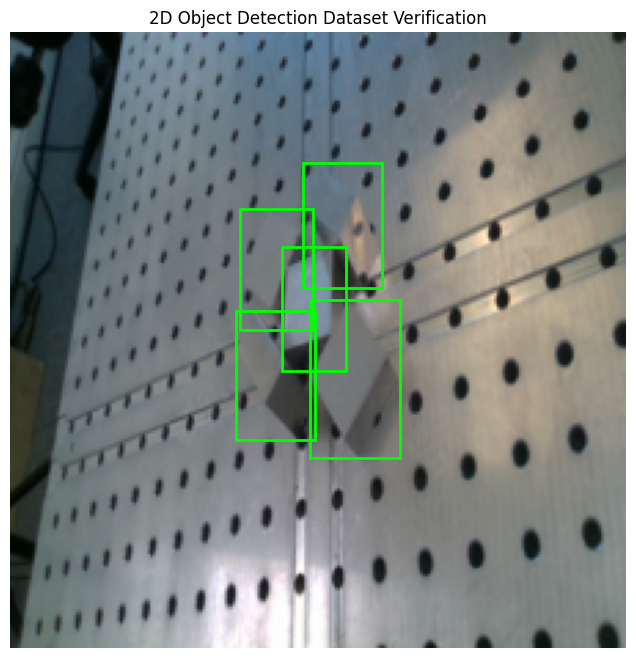

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Let's verify the 2D bounding boxes
img_t, target = detection_train_dataset[499]

# Convert tensor back to HWC numpy image for plotting
img_display = img_t.numpy().transpose(1, 2, 0)

fig, ax = plt.subplots(1, figsize=(8, 8))
ax.imshow(img_display)

# Draw bounding boxes
for box in target['boxes']:
    xmin, ymin, xmax, ymax = box.numpy()
    width, height = xmax - xmin, ymax - ymin
    rect = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='lime', facecolor='none')
    ax.add_patch(rect)

plt.title("2D Object Detection Dataset Verification")
plt.axis('off')
plt.show()

## Object Detection: Model & DataLoader
Faster R-CNN requires a custom `collate_fn` because each image can have a variable number of bounding boxes. We will use a pre-trained ResNet-50 FPN backbone and modify the box predictor head for our 2 classes (Background + Object).

In [ ]:
from torch.utils.data import DataLoader
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def collate_fn(batch):
    # Faster R-CNN expects a tuple of (images, targets) rather than stacked tensors
    # because the number of bounding boxes varies per image.
    return tuple(zip(*batch))

# Create DataLoader
batch_size = 8
train_loader_det = DataLoader(
    detection_train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

def get_detection_model(num_classes):
    # Load a pre-trained Faster R-CNN model
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # Replace the pre-trained head with a new one for our number of classes
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

# 2 classes: background (0) and object (1)
num_classes = 2
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

detection_model = get_detection_model(num_classes)
detection_model.to(device)
print(f"Faster R-CNN model loaded on {device}.")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 192MB/s]


Faster R-CNN model loaded on cuda.


## Training Loop
In PyTorch, Faster R-CNN automatically computes the classification and bounding box regression losses when in `.train()` mode.

In [ ]:
import torch.optim as optim
import time

# Optimizer and Learning Rate Scheduler
params = [p for p in detection_model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

num_epochs = 5

print("Starting training...")
for epoch in range(num_epochs):
    detection_model.train()
    epoch_loss = 0
    start_time = time.time()

    for images, targets in train_loader_det:
        # Move images and targets to device
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Faster R-CNN outputs a dictionary of losses during training
        loss_dict = detection_model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        # Backpropagation
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

    # Update learning rate
    lr_scheduler.step()

    avg_loss = epoch_loss / len(train_loader_det)
    print(f"Epoch [{epoch+1}/{num_epochs}] | Time: {time.time() - start_time:.1f}s | Avg Loss: {avg_loss:.4f}")

print("Training finished!")

Starting training...
Epoch [1/5] | Time: 99.7s | Avg Loss: 0.2566


## Evaluation & Visualization
Let's put the model in `.eval()` mode and visualize the predicted bounding boxes compared to the ground truth.

In [ ]:
detection_model.eval()

num_vis = 4
fig, axes = plt.subplots(1, num_vis, figsize=(20, 5))

with torch.no_grad():
    for i in range(num_vis):
        # Fetch some images from the dataset
        img_t, target = detection_train_dataset[i + 100]

        # Forward pass (expects a list of tensors)
        prediction = detection_model([img_t.to(device)])[0]

        # Format image for matplotlib
        img_display = img_t.numpy().transpose(1, 2, 0)
        ax = axes[i]
        ax.imshow(img_display)

        # Draw Ground Truth (Lime, semi-transparent)
        for box in target['boxes']:
            xmin, ymin, xmax, ymax = box.numpy()
            rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                     linewidth=3, edgecolor='lime', facecolor='none', alpha=0.6)
            ax.add_patch(rect)

        # Draw Predictions (Red)
        boxes = prediction['boxes'].cpu().numpy()
        scores = prediction['scores'].cpu().numpy()

        # Filter by a confidence score threshold
        confidence_threshold = 0.5
        for box, score in zip(boxes, scores):
            if score > confidence_threshold:
                xmin, ymin, xmax, ymax = box
                rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                         linewidth=2, edgecolor='red', facecolor='none')
                ax.add_patch(rect)
                ax.text(xmin, ymin - 5, f"{score:.2f}", color='white', fontsize=10, fontweight='bold',
                        bbox=dict(facecolor='red', alpha=0.7, edgecolor='none', pad=1))

        ax.set_title(f"Sample {i+1}")
        ax.axis('off')

plt.suptitle("Faster R-CNN: Ground Truth (Lime) vs Prediction (Red)", fontsize=16)
plt.tight_layout()
plt.show()

# Sandbox

In [5]:
import json

# Read the attached notebook
with open('/content/lab_2_23.ipynb', 'r') as f:
    notebook = json.load(f)

gradcam_cells = []
for cell in notebook.get('cells', []):
    if cell['cell_type'] == 'code':
        source = "".join(cell.get('source', []))
        # Look for cells containing gradcam or similar keywords
        if 'cam' in source.lower() or 'grad' in source.lower():
            gradcam_cells.append(source)

for i, src in enumerate(gradcam_cells):
    print(f"--- Grad-CAM snippet {i+1} ---")
    print(src[:800]) # Print first 800 chars to identify the method
    print("\n")

if not gradcam_cells:
    print("No Grad-CAM related code found in the notebook.")

--- Grad-CAM snippet 1 ---
%pip install grad-cam


--- Grad-CAM snippet 2 ---
def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    opt.step()
    opt.zero_grad()
    return batch_loss.item()


--- Grad-CAM snippet 3 ---
@torch.no_grad()
def accuracy(x, y, model):
    model.eval()
    logits = model(x)
    is_correct = (logits.argmax(1) == y)  # select class with the highest score (probability)
    return is_correct.cpu().numpy().tolist()


--- Grad-CAM snippet 4 ---
def get_vgg_model():
    model = models.vgg16(pretrained=True)
    for param in model.parameters():
        param.requires_grad = False
    model.avgpool = nn.AdaptiveAvgPool2d(output_size=(1, 1))
    model.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(512, 128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, N_CLASSES) # multi-class classification
    )
    loss_fn = nn.CrossEnt

In [14]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 81.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=f1dcb86ff91efebe0d303f1abefdfc40944db65518bfaba6891cbdc9c6ac3af4
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [15]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# 1. Select the target layer.
# For torchvision's Faster R-CNN with ResNet50-FPN,
# the backbone's layer4 is a rich feature map for visualization.
target_layers = [detection_model.backbone.body.layer4]

# 2. Initialize EigenCAM
# (EigenCAM uses PCA on the activations and doesn't require class-specific targets or gradients)
cam = EigenCAM(model=detection_model, target_layers=target_layers)

# 3. Get a sample image
img_t, target = detection_train_dataset[102] # Try a sample from the dataset
input_tensor = img_t.unsqueeze(0).to(device)

# 4. Generate the CAM
detection_model.eval()
grayscale_cam = cam(input_tensor=input_tensor)
grayscale_cam = grayscale_cam[0, :] # First image in batch

# 5. Prepare image for visualization
img_display = img_t.numpy().transpose(1, 2, 0)
img_display = np.clip(img_display, 0, 1)

# 6. Overlay CAM on the image
cam_image = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)

# 7. Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(img_display)
axes[0].set_title("Original Image with GT BBoxes")
axes[0].axis('off')

# Draw Ground Truth boxes on the original image to see where the object is
for box in target['boxes']:
    xmin, ymin, xmax, ymax = box.numpy()
    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                             linewidth=2, edgecolor='lime', facecolor='none')
    axes[0].add_patch(rect)

axes[1].imshow(cam_image)
axes[1].set_title("EigenCAM Heatmap (ResNet Layer4)")
axes[1].axis('off')

plt.suptitle("Faster R-CNN: EigenCAM Object Localization", fontsize=16)
plt.tight_layout()
plt.show()

NameError: name 'detection_model' is not defined